In [2]:
pip install --force-reinstall git+https://github.com/amyfricke/clairvoyants.git

  Cloning https://github.com/amyfricke/clairvoyants.git to /tmp/pip-req-build-ri8n5c55
  Running command git clone --filter=blob:none --quiet https://github.com/amyfricke/clairvoyants.git /tmp/pip-req-build-ri8n5c55
  Resolved https://github.com/amyfricke/clairvoyants.git to commit 0571c4c42434d6ca13acf1a04d784aaaf182e373
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Using cached numpy-1.21.6-cp37-cp37m-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (2.1 kB)
  Using cached pandas-1.3.5-cp37-cp37m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (12 kB)
  Using cached scipy-1.7.3-cp37-cp37m-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (2.2 kB)
  Using cached matplotlib-3.5.3-cp37-cp37m-manylinux_2_5_x86_64.manylinux1_x86_64.whl.metadata (6.7 kB)
  Using cached statsmodels-0.13.5-cp37-cp37m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (9.5 kB)
  Using cached pm

  Attempting uninstall: zipp
    Found existing installation: zipp 3.15.0
    Uninstalling zipp-3.15.0:
      Successfully uninstalled zipp-3.15.0
  Attempting uninstall: urllib3
    Found existing installation: urllib3 2.0.7
    Uninstalling urllib3-2.0.7:
      Successfully uninstalled urllib3-2.0.7
  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.7.1
    Uninstalling typing_extensions-4.7.1:
      Successfully uninstalled typing_extensions-4.7.1
  Attempting uninstall: tqdm
    Found existing installation: tqdm 4.67.1
    Uninstalling tqdm-4.67.1:
      Successfully uninstalled tqdm-4.67.1
  Attempting uninstall: threadpoolctl
    Found existing installation: threadpoolctl 3.1.0
    Uninstalling threadpoolctl-3.1.0:
      Successfully uninstalled threadpoolctl-3.1.0
  Attempting uninstall: six
    Found existing installation: six 1.17.0
    Uninstalling six-1.17.0:
      Successfully uninstalled six-1.17.0
  Attempting uninstall: setupto

In this notebook we demonstrate clairvoyant's ability to fit seasonality effects including seasonality that has interactions with one of the features in the features data set. We start by importing the relevant functions from the clairvoyants package plus a few other useful things like pandas and numpy. 

In [5]:
import pandas as pd
import numpy as np
from datetime import datetime
from clairvoyants import Clairvoyant
from clairvoyants import ensemble
from clairvoyants.plot import human_format,  plot_pre_post_actuals_forecast, plot_ensemble
from clairvoyants.utilities import _datetime_delta

Importing plotly failed. Interactive plots will not work.


Next we write a function that runs code that simulates a demand time series that has base effects, a weekly and annual pattern, and effects due to several features of price, competitor activity, marketing spend, and an economic indicator. The competitor activity effect interacts with both the weekly and annual pattern. 

In [34]:
def create_demo_data():
    """
    Create demo data with seasonal patterns and features that should interact with seasonality.
    """
    # Create date range
    dates = pd.date_range('2020-01-01', '2022-12-31', freq='D')
    n_days = len(dates)
    
    # Base demand with trend
    base_demand = 1000 + np.arange(n_days) * 0.5
    
    # Seasonal patterns
    weekly_pattern = 200 * np.sin(2 * np.pi * np.arange(n_days) / 7)  # Weekly seasonality
    annual_pattern = 300 * np.sin(2 * np.pi * np.arange(n_days) / 365.25)  # Annual seasonality
    
    # Create features that should interact with seasonality
    x_features = pd.DataFrame({'dt': dates})
    
    # Marketing spend (should amplify seasonal patterns)
    marketing_base = 1000
    marketing_seasonal = 500 * np.sin(2 * np.pi * np.arange(n_days) / 365.25 + np.pi/2)
    marketing_weekly = 200 * np.sin(2 * np.pi * np.arange(n_days) / 7)
    marketing_trend = np.arange(n_days) * 1.0
    marketing_noise = np.random.normal(0, 100, n_days)
    
    x_features['marketing_spend'] = marketing_base + marketing_seasonal + marketing_weekly + marketing_trend + marketing_noise
    x_features['marketing_spend'] = np.maximum(x_features['marketing_spend'], 0)
    
    # Price (should dampen seasonal patterns)
    price_base = 50
    price_seasonal = 10 * np.sin(2 * np.pi * np.arange(n_days) / 365.25 + np.pi)
    price_weekly = 5 * np.sin(2 * np.pi * np.arange(n_days) / 7 + np.pi)
    price_trend = np.arange(n_days) * 0.05
    price_noise = np.random.normal(0, 2, n_days)
    
    x_features['price'] = price_base + price_seasonal + price_weekly + price_trend + price_noise
    
    # Competitor activity (should affect seasonal strength)
    competitor_base = 0.5
    competitor_seasonal = 0.3 * np.sin(2 * np.pi * np.arange(n_days) / 365.25)
    competitor_noise = np.random.normal(0, 0.1, n_days)
    
    x_features['competitor_activity'] = competitor_base + competitor_seasonal + competitor_noise
    x_features['competitor_activity'] = np.clip(x_features['competitor_activity'], 0, 1)
    
    # Economic indicator (should modulate overall seasonality)
    economic_cycle = 0.2 * np.sin(2 * np.pi * np.arange(n_days) / (365.25 * 2))
    economic_trend = np.arange(n_days) * 0.001
    economic_noise = np.random.normal(0, 0.05, n_days)
    
    x_features['economic_index'] = 1.0 + economic_cycle + economic_trend + economic_noise
    
    # Create feature-seasonal interactions
    
    # Competitor activity affects seasonal strength
    competitor_interaction = -x_features['competitor_activity'] * 0.4 * (weekly_pattern + annual_pattern)
        
    # Combine all effects
    feature_interactions =  3 * competitor_interaction 
    
    # Add noise
    noise = np.random.normal(0, 50, n_days)
    
    # Calculate final demand
    actual = base_demand + weekly_pattern + annual_pattern + feature_interactions + noise
    actual = np.maximum(actual, 0)
    
    # Create main DataFrame
    df = pd.DataFrame({
        'dt': dates,
        'actual': actual
    })
    
    # Create simple holiday calendar
    holidays = []
    for year in range(2020, 2023):
        holidays.extend([
            (datetime(year, 1, 1), 'New Year'),
            (datetime(year, 7, 4), 'Independence Day'),
            (datetime(year, 12, 25), 'Christmas'),
        ])
    
    holidays_df = pd.DataFrame(holidays, columns=['dt', 'holiday'])
    
    return df, x_features, holidays_df


In [35]:
df, x_features, holidays_df = create_demo_data()

# No seasonal interaction term
First we attempt a clairvoyant model that simply captures the effects of the annual and weekly pattern and main effects for the features but no interaction term for the feature we know interacts with the seasonality, `competitor_activity`. We specify both annual seasonality (`perods_trig=365.25`) and weekly seasonality (`periods_agg=[7]`) and an ensemble of 5 models including several SARIMAX models and 2 neural network models. We forecast the final six months for which we have training history to see how the basic seasonality modelling handles the simulated scenario without using the seasonal interaction feature of the forecast engine. 

In [65]:
clair_no_interactions = Clairvoyant(
  models=[ensemble.sarimax_013_011, ensemble.sarimax_003_001, ensemble.auto_sarimax, ensemble.auto_sarif_nnet, ensemble.auto_scarf_nnet],
  periods_agg=[7], periods_trig=[365.25], transform='none',
  holidays_df=holidays_df)
clair_no_interactions.fit_ensemble(
  df=df, x_features=x_features,
  training_end_dt=datetime(2022, 6, 30),
  forecast_end_dt=datetime(2022, 12, 23),
  x_cols_seasonal_interactions=[])


/home/amyrichardson/anaconda3/lib/python3.7/site-packages/statsmodels/base/model.py:606: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  ConvergenceWarning)


Below we the results, though the models did correctly predict a down swing starting in the summer it under estimates the magnitude of this seasonal shift and the actuals remain out of the 90% prediction intervals over most of the 6 month period for which there is a forecast an actuals. 

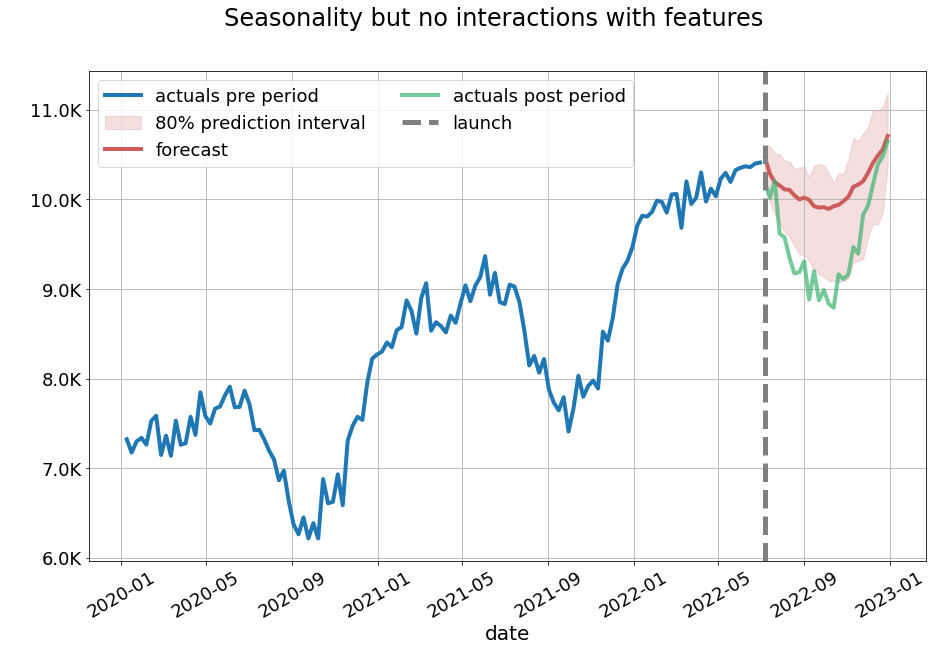

In [66]:
clair_no_interactions = clair_no_interactions.get_out_of_time_validation(
    df=df)

plot_pre_post_actuals_forecast(clair_no_interactions, 
  title='Seasonality but no interactions with features', ylabel=' ',
  pre_period=1200, post_period=50, use_aggregated=True)



# Including seasonal interaction term
Below we refit the same ensemble, but this time we additionally specify `x_cols_seasonal_interactions=['competitor_activity']` to tell clairvoyant to fit an interaction term with this feature to better estimate the seasonality. We know that this interaction exists since this is how we simulated the data. So we expect a better fit to the seasonality with this addition.

In [67]:
clair_with_interactions = Clairvoyant(
  models=[ensemble.sarimax_013_011, ensemble.sarimax_003_001,ensemble.auto_sarimax, ensemble.auto_sarif_nnet, ensemble.auto_scarf_nnet],
  periods_agg=[7], periods_trig=[365.25],
  transform='none',holidays_df=holidays_df)
clair_with_interactions.fit_ensemble(
  df=df,x_features=x_features,
  training_end_dt=datetime(2022, 6, 23),
  forecast_end_dt=datetime(2022, 12, 23),
  x_cols_seasonal_interactions=['competitor_activity'],  # Include the feature that interacts with seasonality
  parallel=True)

As we see below, the annual seasonality fluctuations are captured with much greater accuracy using this set up, as indicated by the forecast closely tracking the actual values and only being off by a small margin. Thus demonstrating the utility of the seasonal interactions feature.The prediction intervals are a lot tighter and nominally contain the actuals in the forecast period. 

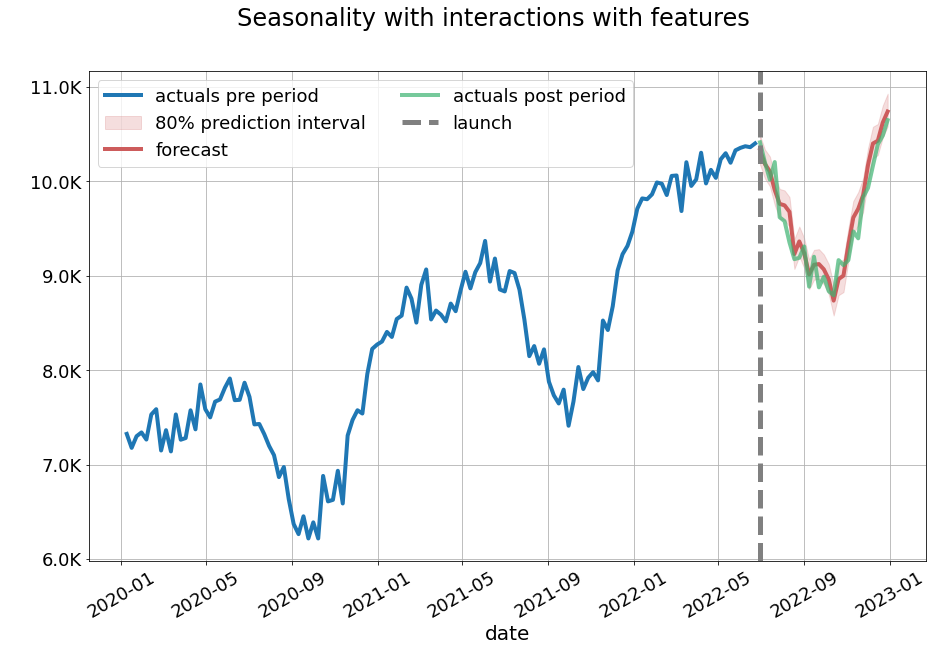

In [68]:
clair_with_interactions = clair_with_interactions.get_out_of_time_validation(
    df=df)

plot_pre_post_actuals_forecast(clair_with_interactions, 
  title='Seasonality with interactions with features', ylabel=' ',
  pre_period=1200, post_period=50, use_aggregated=True)
